# Phase 1 main experiment (part 1b): localization under a label budget

**Why this notebook exists.** Notebook 07 gave the auxiliary model 100k labelled
same-day rows. Under that much supervision the aux model is near-oracle, its SHAP
importance localizes the drifted features on its own, and the frozen model adds
nothing -- so `dual_gain` did not beat `aux_only` (margin -0.044). But 100k
labels from the *current* drifted day is the least realistic assumption in the
whole design: under real drift, labels are the scarce, delayed resource.

**The refined question.** *Does dual-model SHAP degrade more gracefully than
aux_only under limited supervision?* If the stable frozen-model contrast acts as
a useful prior when the aux model is starved of labels, then dual earns its keep
in the regime that actually matters operationally -- and the original hypothesis
survives on the right axis. If it does not, we formally reframe the contribution
to auxiliary-model explanation localization.

**What is held fixed from nb07** (so this is a clean controlled experiment):
the models, the feature contract, the two ground truths (GT1 = KS input-drift,
GT2 = oracle importance), the metrics (precision@K, recall@K), `SHAP_SAMPLE`,
the seeds, the days (Tuesday control + Wed/Thu/Fri drift), and the directional
`dual_gain` as the primary method. **The only thing that varies is
`AUX_TRAIN_CAP`** -- the number of labelled rows the aux model is allowed.

**Chronology / leakage.** Strict at the day level: the frozen model is trained
only on Mon+Tue; the aux model only ever sees a capped subset of the *current*
day; no future day is ever used. Intra-day temporal ordering is not enforced --
the Timestamp column was dropped as a leakage feature in nb03 -- so the
within-day split is random, standing in for "recent labelled traffic." This is a
stated limitation, not a hidden one.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, permutation_disagreement_importance, ks_drift_scores,
    topk_indices, precision_at_k, recall_at_k, jaccard,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
CHECKPOINTS = ROOT / 'experiments' / 'checkpoints'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07b_label_efficiency.json'
for p in (FIGURES, TABLES, CHECKPOINTS):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)

rf_cold = joblib.load(meta06['models']['cold_start'])     # frozen MAIN model
rf_oracle = joblib.load(meta06['models']['oracle'])       # privileged reference (GT2 only)
print(f'Loaded cold_start (main) and oracle. {N_FEATURES} features.')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)

METHOD_COLOR = {
    'dual_gain': '#009E73', 'dual_abs': '#56B4E9', 'aux_only': '#E69F00',
    'main_only': '#999999', 'perm_disagree': '#D55E00', 'random': '#000000',
}
METHOD_LABEL = {
    'dual_gain': 'Dual-gain (method)', 'dual_abs': 'Dual-abs',
    'aux_only': 'Aux-only', 'main_only': 'Main-only',
    'perm_disagree': 'Perm-disagree', 'random': 'Random',
}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png')
    fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07b_label_efficiency'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.')
        return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')


Mounted at /content/drive
Loaded cold_start (main) and oracle. 82 features.
Setup complete.


## 2. D018 -- the label-efficiency sweep, and the pre-registered decision rule

We log the decision *and* the interpretation logic before running anything. The
100k endpoint is already known from nb07 (dual_gain - aux_only = -0.044); the new
information this notebook produces is the **low-label regime**, where the dual
contrast might help.


In [2]:
log_decision(
    decision_id='D018',
    decision=(
        'Re-run the nb07 localization experiment as a sweep over AUX_TRAIN_CAP '
        '(label budget), holding everything else fixed, to test whether '
        'dual_gain degrades more gracefully than aux_only under limited '
        'supervision. Budgets: 250, 1000, 5000, 25000, 100000 labelled rows. '
        'Pre-registered decision rule (committed before execution): '
        '(1) RESCUE -- the dual framing survives if, at some INTERPRETABLE low '
        'budget (post-drift aux_recall >= 0.70 and budget <= 5000), the '
        'post-drift mean precision@10 margin dual_gain - aux_only is >= +0.05 '
        'AND exceeds one standard error above zero. '
        '(2) GRACEFUL-ONLY -- weaker support if dual_gain retains a higher '
        'fraction of its high-budget precision than aux_only does as the budget '
        'falls (relative-retention gap >= 0.10), even without crossing the '
        '+0.05 margin. '
        '(3) REFRAME -- if neither holds, formally reframe the thesis '
        'contribution to auxiliary-model explanation localization; Q007 stands '
        'resolved-negative. Primary metric is unchanged from nb07 (post-drift '
        'mean precision@10 vs GT1); control-day precision@10 is reported as the '
        'specificity lens but does NOT move the rescue goalposts.'
    ),
    rationale=(
        'The 100k-label aux model was the dominant methodological compromise in '
        'nb07 and plausibly favoured aux_only. The operationally relevant '
        'question is label efficiency, not precision under label abundance. '
        'Keeping the primary metric identical to nb07 avoids moving goalposts; '
        'gating the rescue on aux_recall >= 0.70 prevents over-reading budgets '
        'where the aux SHAP is meaningless for both methods.'
    ),
    alternatives=(
        'Make the rescue hinge on a new combined sensitivity+specificity metric '
        '(rejected: invented after seeing nb07, risks p-hacking; reported as '
        'context only). Vary the aux training window across days instead of cap '
        '(rejected: changes infrastructure; deferred to a stricter streaming '
        'test later).'
    ),
)


[DECISION LOGGED] D018


## 3. Configuration

In [3]:
DAYS = ['tuesday', 'wednesday', 'thursday', 'friday']
CONTROL_DAY = 'tuesday'
POST_DRIFT_DAYS = ['wednesday', 'thursday', 'friday']

K_PRIMARY = 10
K_SWEEP = [5, 10, 20]
GT_SIZE = 15
SHAP_SAMPLE = 2000
KS_SAMPLE = 20000
AUX_TRAIN_FRAC = 0.6
SEEDS = [42, 1, 7]

# The one axis that varies:
BUDGETS = [250, 1000, 5000, 25000, 100000]
LOW_LABEL_BUDGETS = [250, 1000, 5000]      # the 'scarce' regime the rescue targets

# Pre-registered thresholds (see D018):
RESCUE_MARGIN = 0.05
AUX_RECALL_MIN = 0.70                       # below this, aux SHAP is not interpretable
GRACEFUL_GAP = 0.10                         # relative-retention gap for the weak rescue

PRIMARY_METHOD = 'dual_gain'
HEADLINE_METHODS = ['dual_gain', 'aux_only', 'perm_disagree', 'random']
ALL_METHODS = ['dual_gain', 'dual_abs', 'aux_only', 'main_only', 'perm_disagree', 'random']
RANDOM_EXPECT = random_precision_expectation(GT_SIZE, N_FEATURES)

print(f'Budgets: {BUDGETS}   (low-label regime: {LOW_LABEL_BUDGETS})')
print(f'Random precision@K = {RANDOM_EXPECT:.3f}  |  seeds: {SEEDS}')
print(f'Rescue: margin >= +{RESCUE_MARGIN} at a budget with aux_recall >= {AUX_RECALL_MIN}')


Budgets: [250, 1000, 5000, 25000, 100000]   (low-label regime: [250, 1000, 5000])
Random precision@K = 0.183  |  seeds: [42, 1, 7]
Rescue: margin >= +0.05 at a budget with aux_recall >= 0.7


## 4. Helpers

Identical to nb07, except `train_or_load_aux` now keys the checkpoint on the
label budget too -- otherwise every budget would silently reuse the same cached
model and the sweep would be flat.


In [4]:
def stratified_sample(X, y, n, seed):
    """Stratified subsample of (X, y) to n rows. Random fallback if single-class."""
    n = min(n, len(y))
    if y.nunique() < 2 or n >= len(y):
        idx = np.random.default_rng(seed).choice(len(y), size=n, replace=False)
        return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)
    idx, _ = train_test_split(np.arange(len(y)), train_size=n,
                              stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


def train_or_load_aux(day, budget, seed, X_tr, y_tr):
    """Train (or load) the auxiliary RF for a given day, label budget, and seed."""
    ckpt = CHECKPOINTS / f'rf_aux_{day}_b{budget}_s{seed}.joblib'
    if ckpt.exists():
        return joblib.load(ckpt)
    params = {**RF_PARAMS, 'random_state': seed}
    rf = RandomForestClassifier(**params).fit(X_tr, y_tr)
    joblib.dump(rf, ckpt)
    return rf


def load_day(day):
    X, y, meta = load_cicids2017(day=day)
    X = X.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
    return X, y, meta

print('Helpers defined.')


Helpers defined.


## 5. Ground truths (identical to nb07, deterministic per day)

Same GT1/GT2 as nb07 so the target is the same and results are directly
comparable. Recomputed here (seed 42) rather than loaded, since nb07 saved only
summary numbers, not the index sets.


In [5]:
X_mon, y_mon, _ = load_day('monday')
mon_X, _ = stratified_sample(X_mon, y_mon, KS_SAMPLE, seed=42)

ground_truth = {}
for day in DAYS:
    Xd, yd, _ = load_day(day)
    day_ks_X, _ = stratified_sample(Xd, yd, KS_SAMPLE, seed=42)
    ks = ks_drift_scores(mon_X, day_ks_X)
    gt1 = topk_indices(ks, GT_SIZE)
    _, ev_idx = train_test_split(np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
                                 stratify=yd if yd.nunique() > 1 else None,
                                 random_state=42)
    Xev42, yev42 = Xd.iloc[ev_idx].reset_index(drop=True), yd.iloc[ev_idx].reset_index(drop=True)
    Xs42, _ = stratified_sample(Xev42, yev42, SHAP_SAMPLE, seed=42)
    gt2 = topk_indices(shap_importance(rf_oracle, Xs42), GT_SIZE)
    ground_truth[day] = {'GT1': gt1, 'GT2': gt2}
    print(f'{day:<10} GT1/GT2 Jaccard={jaccard(gt1, gt2):.3f}   max KS-D={np.max(ks):.3f}')


tuesday    GT1/GT2 Jaccard=0.429   max KS-D=0.076
wednesday  GT1/GT2 Jaccard=0.765   max KS-D=0.333
thursday   GT1/GT2 Jaccard=0.500   max KS-D=0.210
friday     GT1/GT2 Jaccard=0.765   max KS-D=0.456


## 6. The sweep

For each (day, seed) we fix the evaluation sample and the frozen-model importance
once, then vary the label budget: subsample the training pool to `budget` rows,
train the aux model, and recompute the budget-dependent scores. This keeps the
evaluation identical across budgets so only supervision changes.


In [6]:
rows = []
precond = []
t_start = time.time()

for day in DAYS:
    Xd, yd, _ = load_day(day)
    gt1, gt2 = ground_truth[day]['GT1'], ground_truth[day]['GT2']

    for seed in SEEDS:
        tr_idx, ev_idx = train_test_split(
            np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
            stratify=yd if yd.nunique() > 1 else None, random_state=seed)
        Xtr_full = Xd.iloc[tr_idx].reset_index(drop=True)
        ytr_full = yd.iloc[tr_idx].reset_index(drop=True)
        Xev = Xd.iloc[ev_idx].reset_index(drop=True)
        yev = yd.iloc[ev_idx].reset_index(drop=True)

        # fixed across budgets: eval sample + frozen-model importance
        Xs, ys = stratified_sample(Xev, yev, SHAP_SAMPLE, seed)
        imp_main = shap_importance(rf_cold, Xs)

        for budget in BUDGETS:
            Xtr_s, ytr_s = stratified_sample(Xtr_full, ytr_full, budget, seed)
            aux = train_or_load_aux(day, budget, seed, Xtr_s, ytr_s)

            aux_rec = (recall_score(ys, aux.predict(Xs), zero_division=0)
                       if ys.nunique() > 1 else float('nan'))
            precond.append({'day': day, 'seed': seed, 'budget': budget,
                            'n_train': len(ytr_s), 'aux_recall': aux_rec})

            imp_aux = shap_importance(aux, Xs)
            perm = permutation_disagreement_importance(rf_cold, aux, Xs, seed=seed)
            diff = imp_aux - imp_main
            scores = {
                'dual_gain': np.clip(diff, 0, None),
                'dual_abs': np.abs(diff),
                'aux_only': imp_aux,
                'main_only': imp_main,
                'perm_disagree': perm,
                'random': np.random.default_rng(seed).random(N_FEATURES),
            }
            total_div = float(np.abs(diff).sum())
            for mname, sc in scores.items():
                for gtn, gtidx in (('GT1', gt1), ('GT2', gt2)):
                    for k in K_SWEEP:
                        rows.append({
                            'day': day, 'seed': seed, 'budget': budget,
                            'method': mname, 'gt': gtn, 'k': k,
                            'precision': precision_at_k(sc, gtidx, k),
                            'recall': recall_at_k(sc, gtidx, k),
                            'total_divergence': total_div, 'aux_recall': aux_rec,
                        })
    print(f'{day:<10} done  ({time.time()-t_start:.0f}s elapsed)')

res = pd.DataFrame(rows)
precond_df = pd.DataFrame(precond)
res.to_csv(TABLES / '07b_label_efficiency_raw.csv', index=False)
print(f'\n{len(res)} rows.')
print('\nAux-model recall by budget (post-drift days) -- interpretability gate:')
pd_post = precond_df[precond_df['day'].isin(POST_DRIFT_DAYS)]
print(pd_post.groupby('budget')['aux_recall'].mean().round(3).to_string())


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

tuesday    done  (187s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

wednesday  done  (431s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

thursday   done  (635s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

friday     done  (801s elapsed)

2160 rows.

Aux-model recall by budget (post-drift days) -- interpretability gate:
budget
250       0.972
1000      0.986
5000      0.994
25000     0.998
100000    0.999


## 7. Aggregate

In [7]:
def curve(method, days, gtn='GT1', k=K_PRIMARY):
    """Mean/std precision over seeds, per budget, for a method on given days."""
    s = res[(res['method'] == method) & (res['gt'] == gtn)
            & (res['k'] == k) & (res['day'].isin(days))]
    return s.groupby('budget')['precision'].agg(['mean', 'std']).reindex(BUDGETS)

# Post-drift precision@10 table (method x budget)
post_tbl = pd.DataFrame(
    {m: curve(m, POST_DRIFT_DAYS)['mean'] for m in ALL_METHODS}).T[BUDGETS].round(3)
print('Post-drift mean precision@10 vs GT1 (rows=method, cols=budget):\n')
print(post_tbl.to_string())

# Control-day specificity table (lower = better; less false localization)
ctrl_tbl = pd.DataFrame(
    {m: curve(m, [CONTROL_DAY])['mean'] for m in ALL_METHODS}).T[BUDGETS].round(3)
print('\nControl-day (Tuesday) precision@10 vs GT1 -- specificity, lower is better:\n')
print(ctrl_tbl.to_string())

post_tbl.to_csv(TABLES / '07b_postdrift_precision_by_budget.csv')
ctrl_tbl.to_csv(TABLES / '07b_control_precision_by_budget.csv')

# Aux-recall gate per budget
aux_gate = pd_post.groupby('budget')['aux_recall'].mean().reindex(BUDGETS)
print('\nInterpretable budgets (aux_recall >= %.2f):' % AUX_RECALL_MIN,
      [b for b in BUDGETS if aux_gate[b] >= AUX_RECALL_MIN])


Post-drift mean precision@10 vs GT1 (rows=method, cols=budget):

budget         250     1000    5000    25000   100000
dual_gain       0.722   0.678   0.644   0.667   0.667
dual_abs        0.467   0.444   0.433   0.456   0.411
aux_only        0.767   0.756   0.700   0.711   0.711
main_only       0.267   0.267   0.267   0.267   0.267
perm_disagree   0.633   0.489   0.356   0.300   0.378
random          0.178   0.178   0.178   0.178   0.178

Control-day (Tuesday) precision@10 vs GT1 -- specificity, lower is better:

budget         250     1000    5000    25000   100000
dual_gain       0.067   0.000   0.033   0.067   0.000
dual_abs        0.300   0.200   0.233   0.233   0.233
aux_only        0.100   0.167   0.100   0.200   0.200
main_only       0.200   0.200   0.200   0.200   0.200
perm_disagree   0.300   0.367   0.367   0.433   0.367
random          0.133   0.133   0.133   0.133   0.133

Interpretable budgets (aux_recall >= 0.70): [250, 1000, 5000, 25000, 100000]


## 8. Figures

  saved: 07b_precision_vs_budget.png / .pdf


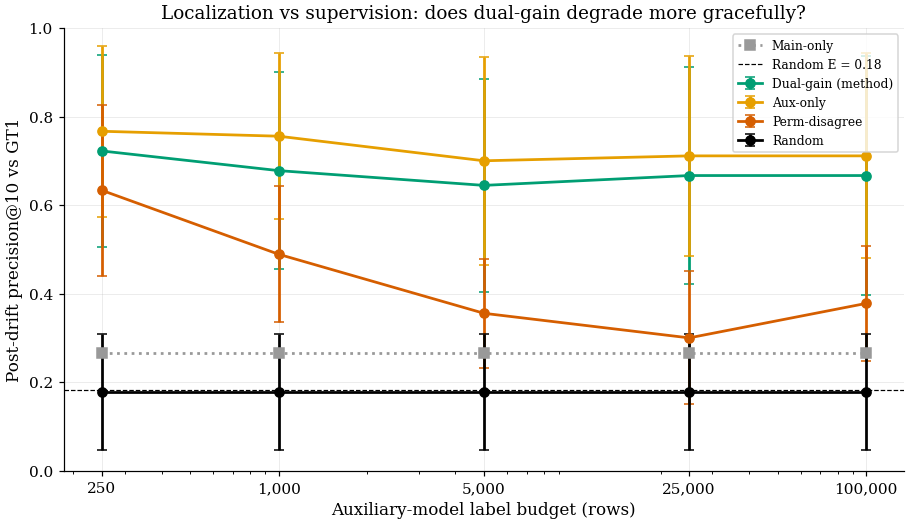

In [8]:
# ----- Figure 1: precision@10 vs label budget (the degradation curves) -----
fig, ax = plt.subplots(figsize=(8.5, 5))
for m in HEADLINE_METHODS:
    c = curve(m, POST_DRIFT_DAYS)
    ax.errorbar(BUDGETS, c['mean'], yerr=c['std'], marker='o', capsize=3,
                color=METHOD_COLOR[m], label=METHOD_LABEL[m])
main_flat = curve('main_only', POST_DRIFT_DAYS)['mean']
ax.plot(BUDGETS, main_flat, ls=':', color=METHOD_COLOR['main_only'],
        marker='s', label=METHOD_LABEL['main_only'])
ax.axhline(RANDOM_EXPECT, ls='--', color='black', lw=0.8,
           label=f'Random E = {RANDOM_EXPECT:.2f}')
ax.set_xscale('log')
ax.set_xticks(BUDGETS); ax.set_xticklabels([f'{b:,}' for b in BUDGETS])
ax.set_xlabel('Auxiliary-model label budget (rows)')
ax.set_ylabel(f'Post-drift precision@{K_PRIMARY} vs GT1')
ax.set_ylim(0, 1.0)
ax.set_title('Localization vs supervision: does dual-gain degrade more gracefully?')
ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, '07b_precision_vs_budget'); plt.show()


  saved: 07b_margin_and_specificity.png / .pdf


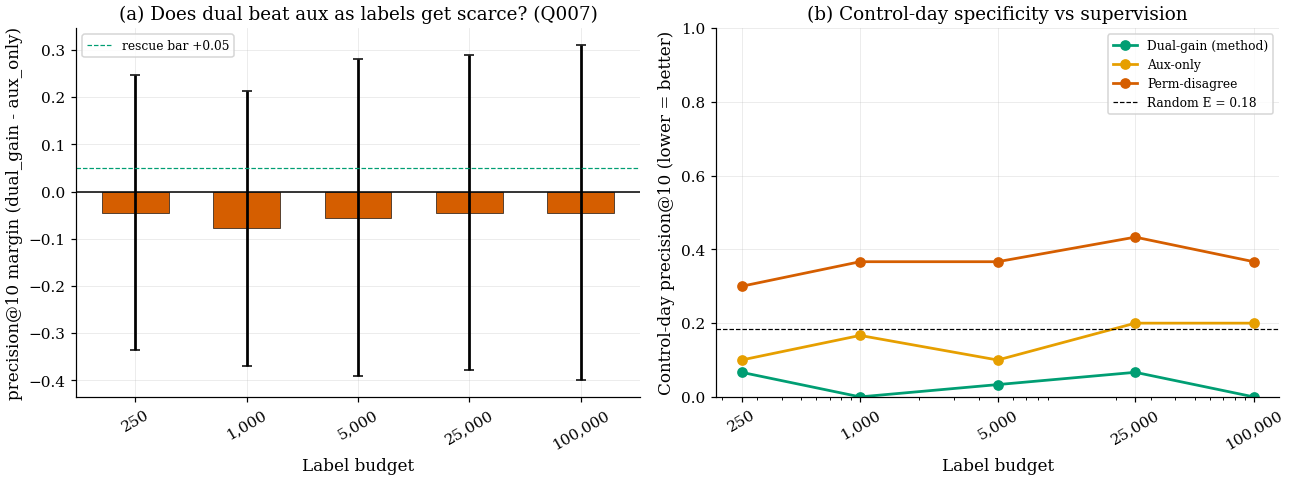

In [9]:
# ----- Figure 2: (a) Q007 margin vs budget   (b) control specificity vs budget -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# (a) margin dual_gain - aux_only across budgets (post-drift)
ax = axes[0]
dg = curve('dual_gain', POST_DRIFT_DAYS)
ao = curve('aux_only', POST_DRIFT_DAYS)
margin = (dg['mean'] - ao['mean'])
err = np.sqrt(dg['std'].fillna(0)**2 + ao['std'].fillna(0)**2)
colors = ['#009E73' if v > 0 else '#D55E00' for v in margin]
ax.bar(range(len(BUDGETS)), margin.values, 0.6, yerr=err.values, capsize=3,
       color=colors, edgecolor='black', linewidth=0.4)
ax.axhline(0, color='black', lw=1.0)
ax.axhline(RESCUE_MARGIN, ls='--', color='#009E73', lw=0.8, label=f'rescue bar +{RESCUE_MARGIN}')
ax.set_xticks(range(len(BUDGETS))); ax.set_xticklabels([f'{b:,}' for b in BUDGETS], rotation=30)
ax.set_xlabel('Label budget'); ax.set_ylabel('precision@10 margin (dual_gain - aux_only)')
ax.set_title('(a) Does dual beat aux as labels get scarce? (Q007)')
ax.legend(fontsize=8)

# (b) control-day specificity across budgets (lower = better)
ax = axes[1]
for m in ['dual_gain', 'aux_only', 'perm_disagree']:
    c = curve(m, [CONTROL_DAY])
    ax.plot(BUDGETS, c['mean'], marker='o', color=METHOD_COLOR[m], label=METHOD_LABEL[m])
ax.axhline(RANDOM_EXPECT, ls='--', color='black', lw=0.8, label=f'Random E = {RANDOM_EXPECT:.2f}')
ax.set_xscale('log'); ax.set_xticks(BUDGETS); ax.set_xticklabels([f'{b:,}' for b in BUDGETS], rotation=30)
ax.set_xlabel('Label budget'); ax.set_ylabel('Control-day precision@10 (lower = better)')
ax.set_ylim(0, 1.0)
ax.set_title('(b) Control-day specificity vs supervision')
ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, '07b_margin_and_specificity'); plt.show()


  saved: 07b_aux_recall_vs_budget.png / .pdf


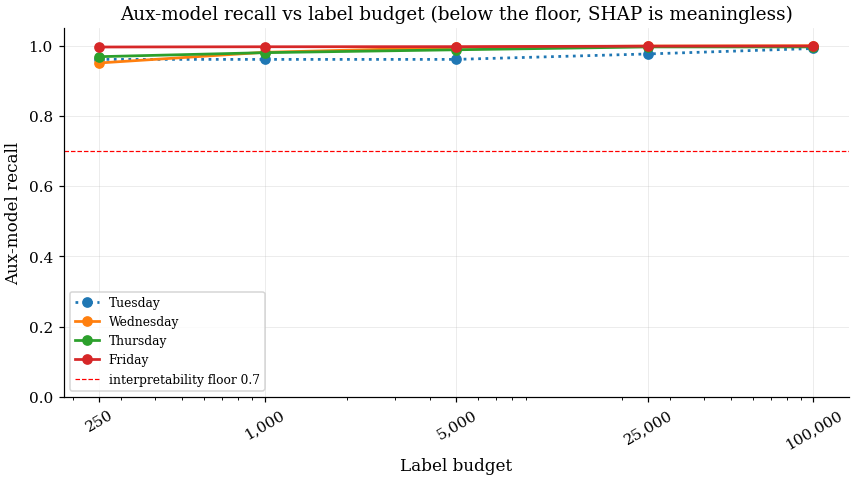

In [10]:
# ----- Figure 3: aux-model recall vs budget per day (validity / precondition) -----
fig, ax = plt.subplots(figsize=(8, 4.6))
for day in DAYS:
    s = precond_df[precond_df['day'] == day]
    g = s.groupby('budget')['aux_recall'].mean().reindex(BUDGETS)
    style = ':' if day == CONTROL_DAY else '-'
    ax.plot(BUDGETS, g, marker='o', ls=style, label=day.capitalize())
ax.axhline(AUX_RECALL_MIN, ls='--', color='red', lw=0.8,
           label=f'interpretability floor {AUX_RECALL_MIN}')
ax.set_xscale('log'); ax.set_xticks(BUDGETS); ax.set_xticklabels([f'{b:,}' for b in BUDGETS], rotation=30)
ax.set_xlabel('Label budget'); ax.set_ylabel('Aux-model recall')
ax.set_ylim(0, 1.05)
ax.set_title('Aux-model recall vs label budget (below the floor, SHAP is meaningless)')
ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, '07b_aux_recall_vs_budget'); plt.show()


## 9. Pre-registered verdict (D018)

Applies the rule committed above. No metric is invented here; the rescue rests on
the same post-drift precision@10 used in nb07, gated on aux interpretability.


In [11]:
dg = curve('dual_gain', POST_DRIFT_DAYS)
ao = curve('aux_only', POST_DRIFT_DAYS)
margin = dg['mean'] - ao['mean']
margin_se = np.sqrt(dg['std'].fillna(0)**2 + ao['std'].fillna(0)**2) / np.sqrt(len(SEEDS))
aux_gate = pd_post.groupby('budget')['aux_recall'].mean().reindex(BUDGETS)

interpretable = [b for b in BUDGETS if aux_gate[b] >= AUX_RECALL_MIN]
low_interp = [b for b in LOW_LABEL_BUDGETS if b in interpretable]

# (1) RESCUE check
rescue_hits = [b for b in low_interp
               if margin[b] >= RESCUE_MARGIN and (margin[b] - margin_se[b]) > 0]

# (2) GRACEFUL check: relative retention low-vs-high budget
b_hi, b_lo = BUDGETS[-1], min(interpretable) if interpretable else BUDGETS[0]
def retention(c):
    hi = c['mean'][b_hi]
    return float(c['mean'][b_lo] / hi) if hi > 0 else float('nan')
dual_ret, aux_ret = retention(dg), retention(ao)
graceful = (dual_ret - aux_ret) >= GRACEFUL_GAP

if rescue_hits:
    verdict = 'RESCUE'
elif graceful:
    verdict = 'GRACEFUL-ONLY'
else:
    verdict = 'REFRAME'

print('=' * 66)
print('LABEL-EFFICIENCY VERDICT (D018)')
print('=' * 66)
print('budget   dual_gain  aux_only   margin   margin_se  aux_recall  interp')
for b in BUDGETS:
    flag = 'yes' if b in interpretable else 'NO '
    print(f'{b:>7}   {dg["mean"][b]:.3f}      {ao["mean"][b]:.3f}     '
          f'{margin[b]:+.3f}    {margin_se[b]:.3f}      {aux_gate[b]:.3f}      {flag}')
print('-' * 66)
print(f'Interpretable low-label budgets : {low_interp}')
print(f'Rescue hits (margin>=+{RESCUE_MARGIN}, >1 SE>0): {rescue_hits}')
print(f'Retention  dual={dual_ret:.2f}  aux={aux_ret:.2f}  '
      f'(low budget {b_lo:,} vs high {b_hi:,})  gap={dual_ret-aux_ret:+.2f}')
print(f'\n--> VERDICT: {verdict}')
if verdict == 'RESCUE':
    print('    Dual framing survives in the label-scarce regime; original hypothesis holds there.')
elif verdict == 'GRACEFUL-ONLY':
    print('    Dual degrades more gracefully but does not clear the +%.2f bar; weak support.' % RESCUE_MARGIN)
else:
    print('    Reframe the contribution to auxiliary-model explanation localization.')


LABEL-EFFICIENCY VERDICT (D018)
budget   dual_gain  aux_only   margin   margin_se  aux_recall  interp
    250   0.722      0.767     -0.044    0.168      0.972      yes
   1000   0.678      0.756     -0.078    0.168      0.986      yes
   5000   0.644      0.700     -0.056    0.194      0.994      yes
  25000   0.667      0.711     -0.044    0.192      0.998      yes
 100000   0.667      0.711     -0.044    0.205      0.999      yes
------------------------------------------------------------------
Interpretable low-label budgets : [250, 1000, 5000]
Rescue hits (margin>=+0.05, >1 SE>0): []
Retention  dual=1.08  aux=1.08  (low budget 250 vs high 100,000)  gap=+0.01

--> VERDICT: REFRAME
    Reframe the contribution to auxiliary-model explanation localization.


## 10. Record to the project log

In [12]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'budgets': BUDGETS, 'seeds': SEEDS, 'k_primary': K_PRIMARY,
    'random_expectation': RANDOM_EXPECT,
    'post_drift_precision_dual_gain': {int(b): float(dg['mean'][b]) for b in BUDGETS},
    'post_drift_precision_aux_only': {int(b): float(ao['mean'][b]) for b in BUDGETS},
    'margin_dual_minus_aux': {int(b): float(margin[b]) for b in BUDGETS},
    'aux_recall_by_budget': {int(b): float(aux_gate[b]) for b in BUDGETS},
    'interpretable_budgets': interpretable,
    'rescue_hits': rescue_hits,
    'retention_dual': dual_ret, 'retention_aux': aux_ret,
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F006',
    title='Label-efficiency of dual-model vs aux-only SHAP localization (notebook 07b)',
    context='03_phase1_cicids/07b_label_efficiency',
    what_we_did=(
        'Swept the auxiliary-model label budget (250 -> 100000 rows) with all else '
        'fixed from nb07, and compared post-drift precision@10 of dual_gain vs '
        'aux_only across budgets, gating interpretability on aux-model recall >= '
        f'{AUX_RECALL_MIN}. Pre-registered rescue/reframe rule (D018).'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Post-drift precision@10 by budget -- dual_gain: '
        + ', '.join(f'{b}:{dg["mean"][b]:.2f}' for b in BUDGETS) + '; aux_only: '
        + ', '.join(f'{b}:{ao["mean"][b]:.2f}' for b in BUDGETS) + '. Margin '
        '(dual-aux) by budget: '
        + ', '.join(f'{b}:{margin[b]:+.2f}' for b in BUDGETS)
        + f'. Interpretable budgets (aux_recall>={AUX_RECALL_MIN}): {interpretable}.'
    ),
    why_it_matters=(
        'Tests the dual framing on the axis that matters operationally (label '
        'scarcity), removing nb07 main compromise. The verdict determines whether '
        'the original dual-model hypothesis survives, survives weakly, or is '
        'formally reframed to auxiliary-model explanation localization before '
        'building the adaptation experiment (nb08).'
    ),
)
print('F006 logged. Now write a hand journal entry recording the call on nb08.')


Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07b_label_efficiency.json
[FINDING LOGGED] F006: Label-efficiency of dual-model vs aux-only SHAP localization (notebook 07b)
F006 logged. Now write a hand journal entry recording the call on nb08.


## 11. What this settles, and the call on notebook 08

- **RESCUE** -> the dual-model framing earns its keep under label scarcity. Build
  nb08 with the dual-triggered adaptation loop as originally planned, but report
  results at a realistic label budget, not 100k.
- **GRACEFUL-ONLY** -> mention the graceful-degradation property honestly, but the
  headline contribution is still auxiliary-model localization; nb08 compares
  aux-only triggering, with dual as a secondary arm.
- **REFRAME** -> formally adopt *auxiliary-model explanation localization* as the
  contribution, and fold in the negative dual result as a genuine insight: when a
  model has collapsed under drift, its explanations carry no localization signal,
  so the degrading production model cannot bootstrap drift localization. nb08 then
  uses aux-only triggering.

Record the decision by hand before moving on:

```python
add_journal_entry(
    title='Notebook 07b label-efficiency verdict and the call on nb08',
    body='...the verdict, the per-budget margins, and which nb08 design follows...',
)
```
